In [2]:
# =========================================
# STOCK PRICE PREDICTION USING LSTM
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models


# -----------------------------------------
# 1. LOAD DATA
# -----------------------------------------
df = pd.read_csv("/content/Day 47 stock_prices.csv")

print(df.head())


         date    ticker     open     high      low    close   volume  \
0  2022-01-03  RELIANCE  2476.84  2496.70  2422.91  2459.80  4940428   
1  2022-01-04  RELIANCE  2443.34  2497.22  2423.41  2460.31  6310409   
2  2022-01-05  RELIANCE  2467.38  2481.76  2408.41  2445.09  2920856   
3  2022-01-06  RELIANCE  2450.52  2472.16  2399.09  2435.63  2458621   
4  2022-01-07  RELIANCE  2415.56  2439.90  2367.79  2403.85  4011166   

   returns_pct  
0      -1.6079  
1       0.0207  
2      -0.6189  
3      -0.3868  
4      -1.3049  


In [3]:
# -----------------------------------------
# 2. PREPROCESS DATA
# -----------------------------------------

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Sort by time (very important)
df = df.sort_values('date')

# Use only closing price
data = df[['close']].values

# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [4]:
# -----------------------------------------
# 3. CREATE SEQUENCES
# -----------------------------------------

window_size = 10  # using last 10 days to predict next day

X, y = [], []

for i in range(window_size, len(data_scaled)):
    X.append(data_scaled[i-window_size:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)


# -----------------------------------------
# 4. TRAIN TEST SPLIT (TIME BASED)
# -----------------------------------------

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [5]:
# -----------------------------------------
# 5. BUILD LSTM MODEL
# -----------------------------------------

model = models.Sequential([
    layers.LSTM(50, return_sequences=False, input_shape=(window_size, 1)),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, batch_size=32)


# -----------------------------------------
# 6. PREDICTION
# -----------------------------------------

pred = model.predict(X_test)

# Convert back to original scale
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)


# -----------------------------------------
# 7. EVALUATION
# -----------------------------------------

rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
print("RMSE:", rmse)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0775
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0650
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0617
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0581
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0582
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0565
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0562
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0569
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0561
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0560
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RMSE: 984.2297637772589


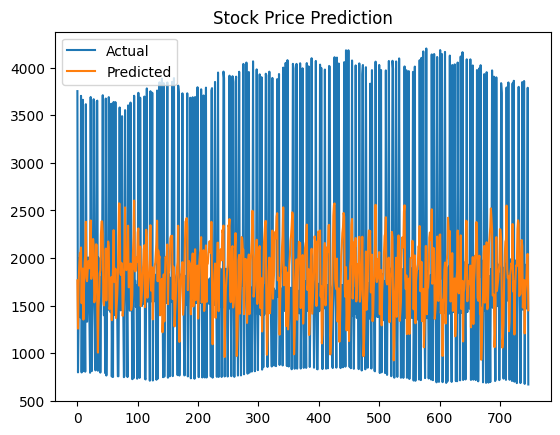

Baseline RMSE: 1122.6661933749383


In [6]:
# -----------------------------------------
# 8. PLOT RESULTS
# -----------------------------------------

plt.plot(y_test_actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()


# -----------------------------------------
# 9. BASELINE MODEL (SIMPLE AVERAGE)
# -----------------------------------------

baseline_pred = []

for i in range(len(X_test)):
    baseline_pred.append(np.mean(X_test[i]))

baseline_pred = scaler.inverse_transform(np.array(baseline_pred).reshape(-1,1))

rmse_baseline = np.sqrt(mean_squared_error(y_test_actual, baseline_pred))

print("Baseline RMSE:", rmse_baseline)